# Multi-Source Answer Synthesis RAG

Real-world enterprise queries cannot rely on a single isolated index. Multi-Source Answer Synthesis gathers evidence from heterogeneous knowledge tools (local FAISS vectorstore, academic ArXiv papers, and global Wikipedia knowledge), evaluates document relevance, and fuses contradictory or complementary facts into a single authoritative synthesis.

## Workflow Architecture

<div align="center">
  <img src="workflow_answer_synthesis.png" alt="Multi-Source Answer Synthesis RAG Architecture Diagram" width="580" />
</div>

<details>
<summary><b>Click to expand Colorful Mermaid Source Code</b></summary>

```mermaid
flowchart TD
    subgraph In["User Query"]
        Q(["1. Multifaceted Query"]):::startNode
    end
    subgraph HeterogeneousRetriever["Multi-Source Knowledge Gathering"]
        Tool1["Local Notes VectorStore<br/><b>FAISS + MiniLM</b>"]:::tool1Node
        Tool2["Academic Research<br/><b>ArXiv Loader</b>"]:::tool2Node
        Tool3["Global Knowledge<br/><b>Wikipedia API</b>"]:::tool3Node
    end
    subgraph SynthesisGraph["LangGraph Synthesis Runtime"]
        Gather["2. retrieve_sources Node<br/>(Queries All Specialized Tools)"]:::gatherNode
        Filter["3. evaluate_context Node<br/><b>Groq LLM Relevance Filter</b>"]:::filterNode
        Synth["4. synthesize_answer Node<br/><b>Groq LLM Unified Synthesis</b>"]:::synthNode
    end
    subgraph Out["Final Output"]
        Ans(["5. Synthesized Multi-Source Answer"]):::endNode
    end
    Q --> Gather
    Gather --> Tool1
    Gather --> Tool2
    Gather --> Tool3
    Tool1 --> Filter
    Tool2 --> Filter
    Tool3 --> Filter
    Filter --> Synth
    Synth --> Ans
    classDef startNode fill:#E8F5E9,stroke:#2E7D32,stroke-width:2px,color:#1B5E20;
    classDef gatherNode fill:#E0F7FA,stroke:#00838F,stroke-width:2px,color:#004D40;
    classDef tool1Node fill:#FFF8E1,stroke:#FFA000,stroke-width:2px,color:#E65100;
    classDef tool2Node fill:#FCE4EC,stroke:#C2185B,stroke-width:2px,color:#880E4F;
    classDef tool3Node fill:#EDE7F6,stroke:#5E35B1,stroke-width:2px,color:#311B92;
    classDef filterNode fill:#E8EAF6,stroke:#3F51B5,stroke-width:2px,color:#1A237E;
    classDef synthNode fill:#E3F2FD,stroke:#1565C0,stroke-width:2px,color:#0D47A1;
    classDef endNode fill:#FFEBEE,stroke:#D32F2F,stroke-width:2px,color:#B71C1C;
```
</details>

### Key Architectural Highlights
- **Heterogeneous Knowledge Fetching**: Integrates local FAISS vectorstores with ArXiv and Wikipedia APIs.
- **Relevance Grading & Filtering**: Filters out noise and tangential paragraphs before final synthesis.
- **Unified Synthesis**: Groq LLM produces an authoritative response with clear attribution.


🎯 Why It’s Needed
Most real-world queries are:
- Multifaceted (require multiple types of information)
- Ambiguous or incomplete (need refinement)
- Open-ended (don’t map to a single document or source)

🔍 This makes retrieving from a single vector DB insufficient.

Instead, we want an agent that can:

- Decide what to fetch from where (retrieval planning)
- Retrieve content from multiple tools (e.g., Wikipedia, PDFs, APIs, SQL)
- Evaluate and merge that context
- Produce a single human-like response

In [10]:
import os
from typing import List
from pydantic import BaseModel
from langchain.chat_models import init_chat_model
from langchain_community.tools import WikipediaQueryRun
from langchain_community.document_loaders import TextLoader, ArxivLoader
from langgraph.graph import StateGraph, END

In [11]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="groq:openai/gpt-oss-120b")
print("LLM ready")

LLM ready


In [12]:
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings

embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

def load_text_retriever(file_path):
    docs = TextLoader(file_path, encoding="utf-8").load()
    splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    chunks = splitter.split_documents(docs)
    vs = FAISS.from_documents(chunks, embedding)
    return vs.as_retriever()

def load_youtube_retriever():
    content = """
    This video explains how agentic AI systems rely on feedback loops, memory, and tool use.
    It compares them to traditional pipeline-based LLMs. Temporal reasoning and autonomous tasking are emphasized.
    """
    doc = Document(page_content=content, metadata={"source": "youtube"})
    vectorstore = FAISS.from_documents([doc], embedding)
    return vectorstore.as_retriever()

def wikipedia_search(query: str) -> str:
    print("🌐 Searching Wikipedia...")
    try:
        import wikipedia
        wikipedia.set_user_agent("AgenticRAGApp/1.0 (contact: admin@example.com)")
        tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=800))
        return tool.run(query)
    except Exception as e:
        return f"Wikipedia search note: {e}"

def arxiv_search(query: str) -> str:
    print("📄 Searching ArXiv...")
    try:
        clean_q = " ".join(query.replace("?", "").replace(":", "").split()[:3])
        results = ArxivLoader(query=clean_q, load_max_docs=1).load()
        return "\n\n".join(doc.page_content[:800] for doc in results[:1]) or "No relevant papers found."
    except Exception as e:
        return f"ArXiv search note: {e}"


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7860.50it/s]


In [13]:
# BUG FIXED: internal_docs.txt does not exist — using research_notes.txt instead
text_retriever    = load_text_retriever("research_notes.txt")
youtube_retriever = load_youtube_retriever()
print("✅ Retrievers ready")

✅ Retrievers ready


In [14]:
### state
class MultiSourceRAGState(BaseModel):
    question: str
    text_docs: List[Document] = []
    yt_docs: List[Document] = []
    wiki_context: str = ""
    arxiv_context: str = ""
    final_answer: str = ""

In [15]:
### Retrieval Nodes
def retrieve_text(state: MultiSourceRAGState) -> MultiSourceRAGState:
    docs = text_retriever.invoke(state.question)
    return state.model_copy(update={"text_docs": docs})

def retrieve_yt(state: MultiSourceRAGState) -> MultiSourceRAGState:
    docs = youtube_retriever.invoke(state.question)
    return state.model_copy(update={"yt_docs": docs})

def retrieve_wikipedia(state: MultiSourceRAGState) -> MultiSourceRAGState:
    result = wikipedia_search(state.question)
    return state.model_copy(update={"wiki_context": result})

def retrieve_arxiv(state: MultiSourceRAGState) -> MultiSourceRAGState:
    result = arxiv_search(state.question)
    return state.model_copy(update={"arxiv_context": result})

In [16]:
## synthesize
def synthesize_answer(state: MultiSourceRAGState) -> MultiSourceRAGState:
    
    context = ""

    context += "\n\n[Internal Docs]\n" + "\n".join([doc.page_content for doc in state.text_docs])
    context += "\n\n[YouTube Transcript]\n" + "\n".join([doc.page_content for doc in state.yt_docs])
    context += "\n\n[Wikipedia]\n" + state.wiki_context
    context += "\n\n[ArXiv]\n" + state.arxiv_context

    prompt = f"""You have retrieved relevant context from multiple sources. Now synthesize a complete and coherent answer.

Question: {state.question}

Context:
{context}

Final Answer:"""

    answer = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"final_answer": answer})

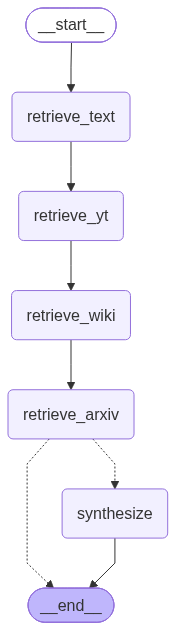

In [17]:
from langgraph.graph import StateGraph, START, END
from typing import Literal

def check_content(state: MultiSourceRAGState) -> Literal["synthesize", "__end__"]:
    """
    Quality gate: only call the LLM synthesizer if at least one
    source returned content. Prevents empty-context hallucination.
    """
    has_content = (
        bool(state.text_docs)
        or bool(state.yt_docs)
        or bool(state.wiki_context.strip())
        or bool(state.arxiv_context.strip())
    )
    if has_content:
        print("✅ Content retrieved from at least one source — synthesizing...")
        return "synthesize"
    print("⚠️  No content retrieved from any source — ending early.")
    return END

builder = StateGraph(MultiSourceRAGState)

# ── Register nodes ─────────────────────────────────────────────────────────────
builder.add_node("retrieve_text",  retrieve_text)
builder.add_node("retrieve_yt",    retrieve_yt)
builder.add_node("retrieve_wiki",  retrieve_wikipedia)
builder.add_node("retrieve_arxiv", retrieve_arxiv)
builder.add_node("synthesize",     synthesize_answer)

# ── Sequential chain: each retrieval enriches one field of the shared state ────
#   NOTE: Parallel fan-out requires TypedDict + Annotated reducers.
#         Pydantic BaseModel states don't support concurrent writes — use sequential.
builder.set_entry_point("retrieve_text")
builder.add_edge("retrieve_text",  "retrieve_yt")
builder.add_edge("retrieve_yt",    "retrieve_wiki")
builder.add_edge("retrieve_wiki",  "retrieve_arxiv")

# ── Conditional gate after all retrievals complete ─────────────────────────────
builder.add_conditional_edges(
    "retrieve_arxiv",
    check_content,
    {"synthesize": "synthesize", END: END}
)

builder.add_edge("synthesize", END)

graph = builder.compile()
graph

# Graph Visualization
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())


In [18]:
question = "What are transformer agents and how are they evolving in recent research?"
state = MultiSourceRAGState(question=question)
result = graph.invoke(state)

print("✅ Final Answer:\n")
print(result["final_answer"])


🌐 Searching Wikipedia...
📄 Searching ArXiv...


HTTPError: Page request resulted in HTTP 406 (https://export.arxiv.org/api/query?search_query=What+are+transformer+agents+and+how+are+they+evolving+in+recent+research%3F&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100)

In [ ]:
result

{'question': 'What are transformer agents and how are they evolving in recent research?',
 'text_docs': [Document(id='dc4b9d44-f3fb-42ca-a609-3a02a5576db9', metadata={'source': 'internal_docs.txt'}, page_content='Additional Notes:\n\n- Vision transformers (ViT and Swin Transformer) evaluated in manufacturing QC tasks.\n- Speech transformers (Wav2Vec 2.0) benchmarked for voice assistant integrations.\n- Tokenizers: SentencePiece, BPE, and unigram tokenizers compared for multilingual tasks.\n- Significant improvements noted with FlashAttention and Rotary Positional Encoding.'),
  Document(id='6270b5df-3ab0-4e8c-8708-9072ea8b93e8', metadata={'source': 'internal_docs.txt'}, page_content='Title: Transformer Variants for Production\n\nWe have used the following transformer variants in production deployments:\n\n1. EfficientFormer:\n   - Optimized for mobile inference.\n   - Deployed in multiple mobile and edge environments.\n   - Quantized using ONNX and optimized via TensorRT.\n   - Benchma